# Notebook 06 — ewm-ops: the operational graph boots like an OS

This notebook drives the **operational graph** (`ewm-ops`) through its CLI:

- a **boot file** (content-addressed DSL script) defines values, programs (`def`), links, and the boot stack;
- the CLI boots: loads the default boot file, compiles the graph, **picks up the persisted state from the top of the stack**, and runs the stack-pop dispatcher;
- the dispatcher fires [UM]s when their in-ports fill; fan-out is by reference; the fire sequence is deterministic;
- `--repo` commits the fire log into an `ewm-git` loose store.

The demo graph: `union2` consumes two values, then `dup2` feeds its own output back into itself (a feedback cycle), bounded by a fire budget.

In [1]:
import json
import pathlib
import subprocess
import shutil

ROOT = pathlib.Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent  # nbconvert executes inside the notebook dir
BIN = ROOT / 'target' / 'debug' / 'ewm-ops'
STORE = ROOT / 'target' / 'nb06-store'
REPO = STORE / 'repo'

def run_ops(*args):
    proc = subprocess.run([str(BIN), *args], capture_output=True, text=True)
    if proc.returncode != 0:
        raise RuntimeError(proc.stderr.strip())
    return json.loads(proc.stdout)

shutil.rmtree(STORE, ignore_errors=True)
STORE.mkdir(parents=True, exist_ok=True)
print(f'binary: {BIN}')
print(f'store:  {STORE}')

binary: /home/alexmy/SGS/SGS_lib/fractal_manifold_gen2/ewm-state-machine/target/debug/ewm-ops
store:  /home/alexmy/SGS/SGS_lib/fractal_manifold_gen2/ewm-state-machine/target/nb06-store


In [2]:
BOOT = '''
# notebook 06 boot: fan-out union, then a dup feedback loop
value a apple
value b banana cherry
def union2 ( 2 -- 1 ) union
def dup2 ( 1 -- 2 ) dup
link value:@a -> in:union2.0
link value:@b -> in:union2.1
link out:union2.0 -> in:dup2.0
link out:dup2.0 -> in:dup2.0
stack @a @b
fires 12
'''
boot_path = STORE / 'boot.ops'
boot_path.write_text(BOOT)
print(boot_path.read_text())


# notebook 06 boot: fan-out union, then a dup feedback loop
value a apple
value b banana cherry
def union2 ( 2 -- 1 ) union
def dup2 ( 1 -- 2 ) dup
link value:@a -> in:union2.0
link value:@b -> in:union2.1
link out:union2.0 -> in:dup2.0
link out:dup2.0 -> in:dup2.0
stack @a @b
fires 12



## First boot: install the boot file and run with the fire budget

`--boot` stores the script content-addressed (`b:<sha1>`) and points the default at it. `--repo` makes every fire record a commit.

In [3]:
first = run_ops('--store', str(STORE), '--boot', str(boot_path), '--fires', '12', '--repo', str(REPO))
print(json.dumps({
    'boot': first['boot'],
    'commit_point': first['commit_point'],
    'fires': len(first['fire_log']['records']),
    'state': first['state'],
    'commits': first['commits'] and len(first['commits']),
}, indent=2))

{
  "boot": "b:59b494496a6862ce684ba731e9918741f91bb098",
  "commit_point": {
    "fired": 12,
    "reason": "FireBudget"
  },
  "fires": 12,
  "state": "h:235654efd45b27bd8a67218aeee715bf80426406",
  "commits": 12
}


In [4]:
ops = first['graph']['ops']['ops']  # OpTable nests its map under 'ops'
labels = {cid: spec['expr']['source'] for cid, spec in ops.items()}
for rec in first['fire_log']['records']:
    print(f"{rec['op'][:12]}  {labels[rec['op']]:22s}  in={len(rec['inputs'])}  out={len(rec['outputs'])}")

p:49120ae424  2 1 union               in=2  out=1
p:c0d45099fc  1 2 dup                 in=1  out=2
p:c0d45099fc  1 2 dup                 in=1  out=2
p:c0d45099fc  1 2 dup                 in=1  out=2
p:c0d45099fc  1 2 dup                 in=1  out=2
p:c0d45099fc  1 2 dup                 in=1  out=2
p:c0d45099fc  1 2 dup                 in=1  out=2
p:c0d45099fc  1 2 dup                 in=1  out=2
p:c0d45099fc  1 2 dup                 in=1  out=2
p:c0d45099fc  1 2 dup                 in=1  out=2
p:c0d45099fc  1 2 dup                 in=1  out=2
p:c0d45099fc  1 2 dup                 in=1  out=2


## Second boot: the state is picked up from the top of the stack

No `--boot`, no `--fires`, no `--repo`: the machine goes to the default boot file and restores the persisted stack. The top of the stack is the current state.

In [5]:
second = run_ops('--store', str(STORE))
print(json.dumps({
    'boot': second['boot'],
    'commit_point': second['commit_point'],
    'seed_stack_len': len(second['seed_stack']),
    'state': second['state'],
}, indent=2))
assert second['seed_stack'] == first['stack'], 'boot restored the persisted stack'
assert second['state'] == first['state'], 'the top of the stack is the current state'
print('OK: persisted state restored from the top of the stack')

{
  "boot": "b:59b494496a6862ce684ba731e9918741f91bb098",
  "commit_point": {
    "fired": 0,
    "reason": "Quiescence"
  },
  "seed_stack_len": 23,
  "state": "h:235654efd45b27bd8a67218aeee715bf80426406"
}
OK: persisted state restored from the top of the stack


## Fire-sequence plots

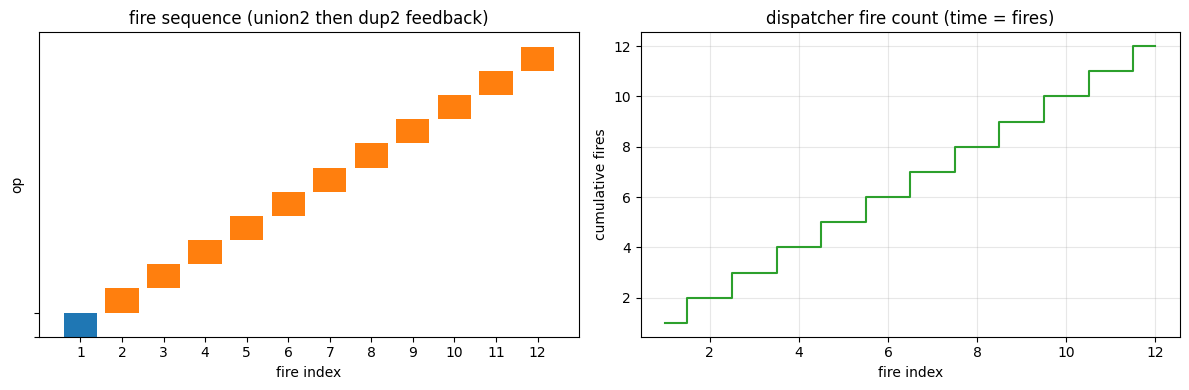

In [6]:
import matplotlib.pyplot as plt

records = first['fire_log']['records']
op_labels = [labels[r['op']].split(' ')[-1] for r in records]
cum = [i + 1 for i in range(len(records))]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

colors = ['tab:blue' if l == 'union' else 'tab:orange' for l in op_labels]
ax1.bar(cum, [1]*len(records), bottom=cum, color=colors, width=0.8)
ax1.set_xticks(cum)
ax1.set_xlabel('fire index')
ax1.set_ylabel('op')
ax1.set_title('fire sequence (union2 then dup2 feedback)')
ax1.set_yticks([1, 2])
ax1.set_yticklabels([])

ax2.step(range(1, len(records) + 1), cum, where='mid', color='tab:green')
ax2.set_xlabel('fire index')
ax2.set_ylabel('cumulative fires')
ax2.set_title('dispatcher fire count (time = fires)')
ax2.grid(alpha=0.3)

fig.tight_layout()
plt.show()

## Boot report (truncated)

The full report is a single JSON object: `boot` (the boot-file CID), `graph` (values + ops + edges), `fire_log` (the trajectory), `stack` (bottom → top), `state` (the top), and `commits`.

In [7]:
slim = {
    'boot': first['boot'],
    'store': first['store'],
    'commit_point': first['commit_point'],
    'fire_log.records': len(first['fire_log']['records']),
    'stack_len': len(first['stack']),
    'state': first['state'],
    'commits': first['commits'] and len(first['commits']),
}
print(json.dumps(slim, indent=2))

{
  "boot": "b:59b494496a6862ce684ba731e9918741f91bb098",
  "store": "/home/alexmy/SGS/SGS_lib/fractal_manifold_gen2/ewm-state-machine/target/nb06-store",
  "commit_point": {
    "fired": 12,
    "reason": "FireBudget"
  },
  "fire_log.records": 12,
  "stack_len": 23,
  "state": "h:235654efd45b27bd8a67218aeee715bf80426406",
  "commits": 12
}
